In [1]:
!pip install pandas
!pip install matplotlib
!pip install researchpy
!pip install scipy
!pip install statsmodels

<Figure size 1000x600 with 0 Axes>

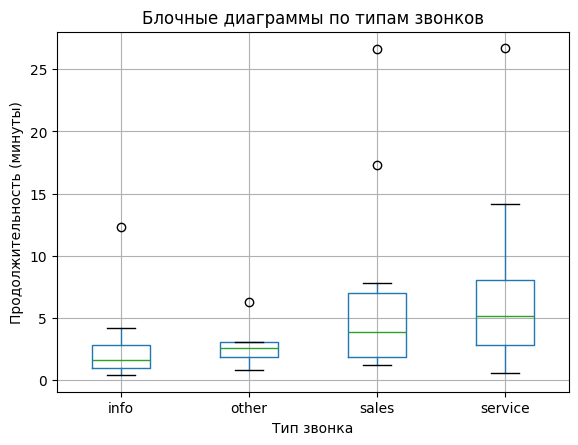

Описательные статистики по видам звонков:


          N    Mean      SD      SE  95% Conf.  Interval
call                                                    
info     13  2.6077  3.1473  0.8729     0.7058    4.5096
other     7  2.7857  1.7827  0.6738     1.1370    4.4345
sales    17  5.8706  6.6210  1.6058     2.4664    9.2748
service  15  7.1933  6.7180  1.7346     3.4730   10.9137

Наибольшая средняя продолжительность у звонков типа: service
Наименьшая средняя продолжительность у звонков типа: info

Shapiro-Wilk тест на нормальность (вся выборка):
Статистика = 0.6967, p-значение = 0.0000

Shapiro-Wilk тест по каждому типу звонка:
info: Статистика = 0.6515, p-значение = 0.0002
other: Статистика = 0.8701, p-значение = 0.1862
sales: Статистика = 0.6816, p-значение = 0.0001
service: Статистика = 0.8054, p-значение = 0.0043

Levene-тест на равенство дисперсий:
Статистика = 1.3381, p-значение = 0.2731


<Figure size 1000x600 with 0 Axes>

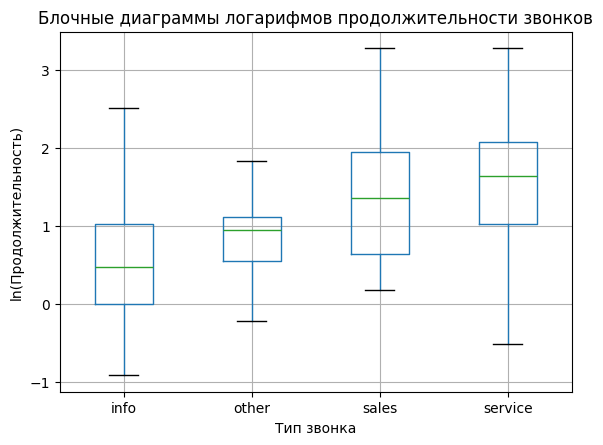


Levene-тест на равенство дисперсий (логарифмы):
Статистика = 0.4510, p-значение = 0.7177

Shapiro-Wilk тест по логарифмам, по каждому типу звонка:
info: Статистика = 0.9747, p-значение = 0.9431
other: Статистика = 0.9352, p-значение = 0.5957
sales: Статистика = 0.9453, p-значение = 0.3858
service: Статистика = 0.9757, p-значение = 0.9317


In [3]:
# Задание 1: Анализ качества работы операторов на основе времени звонков

# 1) Импортируем библиотеки и загружаем данные
import pandas as pd
import numpy as np
import researchpy as rp
import matplotlib.pyplot as plt
import scipy.stats as stats

df = pd.read_csv("anova_lab1.csv")

# 2) Построение блочных диаграмм по типам звонков
plt.figure(figsize=(10, 6))
boxplot = df.boxplot(by='call')
plt.title("Блочные диаграммы по типам звонков")
plt.suptitle("")  # убираем автоматический заголовок
plt.xlabel("Тип звонка")
plt.ylabel("Продолжительность (минуты)")
plt.grid(True)
plt.show()

# 3) Вычисление описательных статистик по типам звонков
print("Описательные статистики по видам звонков:")
stats_summary = rp.summary_cont(df['length'].groupby(df['call']))
print(stats_summary)

# 4) Какой тип звонка имеет наибольшую и наименьшую среднюю продолжительность?
max_call = stats_summary['Mean'].idxmax()
min_call = stats_summary['Mean'].idxmin()
print(f"\nНаибольшая средняя продолжительность у звонков типа: {max_call}")
print(f"Наименьшая средняя продолжительность у звонков типа: {min_call}")

# 5) Проверка нормальности распределения по всему массиву данных
shapiro_test = stats.shapiro(df['length'])
print("\nShapiro-Wilk тест на нормальность (вся выборка):")
print(f"Статистика = {shapiro_test.statistic:.4f}, p-значение = {shapiro_test.pvalue:.4f}")

# Дополнительно: проверим нормальность по группам
print("\nShapiro-Wilk тест по каждому типу звонка:")
for name, group in df.groupby('call'):
    stat, p = stats.shapiro(group['length'])
    print(f"{name}: Статистика = {stat:.4f}, p-значение = {p:.4f}")

# Проверка гомогенности дисперсий (равенство вариаций)
levene_test = stats.levene(
    *[group['length'].values for name, group in df.groupby('call')]
)
print("\nLevene-тест на равенство дисперсий:")
print(f"Статистика = {levene_test.statistic:.4f}, p-значение = {levene_test.pvalue:.4f}")

# 6) Копируем данные и берём натуральный логарифм продолжительности звонков
dfLog = df.copy()
dfLog['length'] = np.log(dfLog['length'])

# 7) Построение блочных диаграмм для логарифмов продолжительности
plt.figure(figsize=(10, 6))
boxplot_log = dfLog.boxplot(by='call')
plt.title("Блочные диаграммы логарифмов продолжительности звонков")
plt.suptitle("")
plt.xlabel("Тип звонка")
plt.ylabel("ln(Продолжительность)")
plt.grid(True)
plt.show()

# Проверка гомогенности дисперсий после логарифмирования
levene_test_log = stats.levene(
    *[group['length'].values for name, group in dfLog.groupby('call')]
)
print("\nLevene-тест на равенство дисперсий (логарифмы):")
print(f"Статистика = {levene_test_log.statistic:.4f}, p-значение = {levene_test_log.pvalue:.4f}")

# Дополнительно: проверка нормальности для логарифмов по группам
print("\nShapiro-Wilk тест по логарифмам, по каждому типу звонка:")
for name, group in dfLog.groupby('call'):
    stat, p = stats.shapiro(group['length'])
    print(f"{name}: Статистика = {stat:.4f}, p-значение = {p:.4f}")

В обоих случаях p > 0.05, то есть гипотеза о равенстве дисперсий не отвергается.

Однако у логарифмов p-значение существенно выше — 0.7177, что указывает на более сильную поддержку гипотезы о равенстве дисперсий.

Также блочные диаграммы логарифмов визуально демонстрируют более похожие размеры "ящиков" и "усов", то есть меньшую разницу в разбросе между группами.

In [4]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# ANOVA-модель: логарифм продолжительности ~ тип звонка
model = ols('length ~ call', data=dfLog).fit()
aov_table = sm.stats.anova_lm(model, typ=2)
print(aov_table)

             sum_sq    df         F    PR(>F)
call       9.423681   3.0  3.851057  0.015055
Residual  39.152601  48.0       NaN       NaN


In [5]:
import statsmodels.stats.multicomp as mc

comp = mc.MultiComparison(dfLog['length'], dfLog['call'])
post_hoc_res = comp.tukeyhsd()
print(post_hoc_res)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1  group2 meandiff p-adj   lower  upper  reject
----------------------------------------------------
  info   other   0.3274 0.8661 -0.7994 1.4543  False
  info   sales   0.8411 0.0682 -0.0444 1.7267  False
  info service   1.0671 0.0157  0.1563 1.9779   True
 other   sales   0.5137 0.5883 -0.5657 1.5932  False
 other service   0.7397  0.291 -0.3606 1.8399  False
 sales service   0.2259 0.8941 -0.6255 1.0774  False
----------------------------------------------------


Тип звонка влияет на продолжительность (в логарифмах).
Звонки типа service статистически дольше звонков типа info.
Остальные различия между типами звонков статистически не подтверждаются.


In [6]:
import pandas as pd
import numpy as np
import researchpy as rp
import matplotlib.pyplot as plt
from statsmodels.graphics.factorplots import interaction_plot

# Загрузка данных
df = pd.read_csv("anova_lab2.csv")

In [7]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Модель с взаимодействием факторов
model = ols('effect ~ C(type) + C(parameter) + C(type):C(parameter)', data=df).fit()

# ANOVA таблица
aov_table = sm.stats.anova_lm(model, typ=2)
print(aov_table)

                       sum_sq    df          F        PR(>F)
C(type)               630.375   1.0  54.486194  7.559419e-07
C(parameter)           39.250   2.0   1.696279  2.113919e-01
C(type):C(parameter)   19.750   2.0   0.853541  4.424370e-01
Residual              208.250  18.0        NaN           NaN


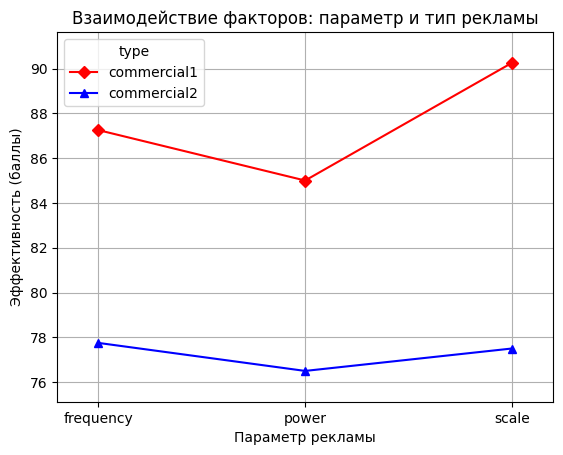

In [9]:
from statsmodels.graphics.factorplots import interaction_plot

fig = interaction_plot(
    x=df['parameter'],       # ось X — параметры рекламы
    trace=df['type'],        # линии — тип рекламы
    response=df['effect'],   # зависимая переменная
    colors=['red', 'blue'],
    markers=['D', '^']
)

plt.title("Взаимодействие факторов: параметр и тип рекламы")
plt.ylabel("Эффективность (баллы)")
plt.xlabel("Параметр рекламы")
plt.grid(True)
plt.show()

3. Значимо ли реклама 1 эффективнее рекламы 2?
Да, тип рекламы статистически значимо влияет на эффективность (p = 7.56e-07 < 0.05).
Из графика видно, что commercial1 всегда выше по эффективности, чем commercial2.

4. Существенно ли взаимодействие факторов?
Нет, p = 0.442 > 0.05.
Взаимодействие незначимо, то есть эффект параметров не зависит от типа рекламы.

5. Существенен ли главный эффект вида рекламы?
Да, p = 7.56e-07.
Тип рекламы влияет на оценку эффективности — одна реклама стабильно лучше другой.

6. Существенен ли главный эффект параметров рекламы?
Нет, p = 0.211 > 0.05.
В среднем разные параметры (frequency, power, scale) не оказывают значимого влияния.

На графике видно:

Красная линия (commercial1) идёт выше синей (commercial2) — это подтверждает влияние типа рекламы.
Линии примерно параллельны, что визуально подтверждает отсутствие взаимодействия между факторами.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Вводим данные вручную из ANOVA-таблицы
anova_data = {
    "Factor": ["Store Type (A)", "Product (B)", "Week (C)"],
    "SS": [1794577789, 25726794801, 246397563],
    "df": [1, 19, 12],
    "MS": [1794577789, 1354041, 2053313],
    "F": [1121.52, 864.21, 12.83],
    "p-value": [0.000, 0.000, 0.000]
}

anova_df = pd.DataFrame(anova_data)
print(anova_df)

           Factor           SS  df          MS        F  p-value
0  Store Type (A)   1794577789   1  1794577789  1121.52      0.0
1     Product (B)  25726794801  19     1354041   864.21      0.0
2        Week (C)    246397563  12     2053313    12.83      0.0


In [11]:
store_p_value = anova_df.loc[anova_df["Factor"] == "Store Type (A)", "p-value"].values[0]
if store_p_value < 0.05:
    print("Различие в 40% между магазинами статистически значимо (p < 0.05)")
else:
    print("Различие не является статистически значимым (p ≥ 0.05)")

Различие в 40% между магазинами статистически значимо (p < 0.05)


Используется трехфакторный дисперсионный анализ

Факторы анализа:
- Store Type (A): 2 категории (универмаг, производитель)
- Product (B): 20 категорий (наименования товаров)
- Week (C): 13 категорий (недели)

In [13]:
product_p_value = anova_df.loc[anova_df["Factor"] == "Product (B)", "p-value"].values[0]
print(f"P-значение для вида товара (Product): {product_p_value}")
if product_p_value < 0.05:
    print("Цены статистически значимо различаются в зависимости от товара.")
else:
    print("Различия цен между товарами незначимы.")

P-значение для вида товара (Product): 0.0
Цены статистически значимо различаются в зависимости от товара.


In [14]:
week_p_value = anova_df.loc[anova_df["Factor"] == "Week (C)", "p-value"].values[0]
print(f"P-значение для недель (Week): {week_p_value}")
if week_p_value < 0.05:
    print("Цены статистически значимо меняются по неделям.")
else:
    print("Неделя не влияет на цену.")

P-значение для недель (Week): 0.0
Цены статистически значимо меняются по неделям.


In [16]:
import pandas as pd

# Повторно создаём расширенную ANOVA-таблицу
anova_extended_data = {
    "Factor": [
        "Store Type (A)", "Product (B)", "Week (C)",
        "A × B", "A × C", "B × C", "A × B × C"
    ],
    "SS": [1794577789, 25726794801, 246397563, 249501890, 24270330, 305870536, 35658621],
    "df": [1, 19, 12, 19, 12, 228, 228],
    "MS": [1794577789, 1354041, 2053313, 13131678, 2022528, 1341792, 156346],
    "F": [1121.52, 864.21, 12.83, 8.22, 1.26, 1.52, 0.97],
    "p-value": [0.000, 0.000, 0.000, 0.000, 0.243, 0.001, 0.503]
}

anova_extended_df = pd.DataFrame(anova_extended_data)

In [17]:
# Анализ взаимодействий по p-value
interactions = {
    "A × B (Store × Product)": anova_extended_df.loc[anova_extended_df["Factor"] == "A × B", "p-value"].values[0],
    "A × C (Store × Week)": anova_extended_df.loc[anova_extended_df["Factor"] == "A × C", "p-value"].values[0],
    "B × C (Product × Week)": anova_extended_df.loc[anova_extended_df["Factor"] == "B × C", "p-value"].values[0],
    "A × B × C": anova_extended_df.loc[anova_extended_df["Factor"] == "A × B × C", "p-value"].values[0]
}

for name, p in interactions.items():
    if p < 0.05:
        print(f"✅ Взаимодействие {name} — значимо (p = {p:.3f})")
    else:
        print(f"❌ Взаимодействие {name} — незначимо (p = {p:.3f})")

✅ Взаимодействие A × B (Store × Product) — значимо (p = 0.000)
❌ Взаимодействие A × C (Store × Week) — незначимо (p = 0.243)
✅ Взаимодействие B × C (Product × Week) — значимо (p = 0.001)
❌ Взаимодействие A × B × C — незначимо (p = 0.503)


<ipython-input-19-60be79add92f>:29: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.pointplot(data=plot_data, x="Week", y="Price", hue="Store", ci=None, markers=["o", "s"], linestyles=["-", "--"])


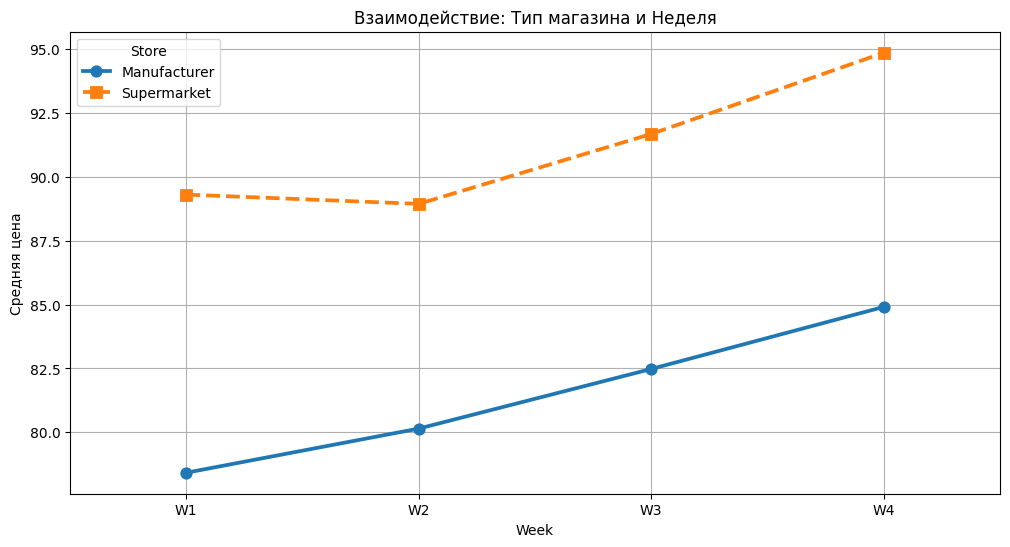

<ipython-input-19-60be79add92f>:36: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.pointplot(data=plot_data, x="Product", y="Price", hue="Store", ci=None, markers=["o", "s"], linestyles=["-", "--"])


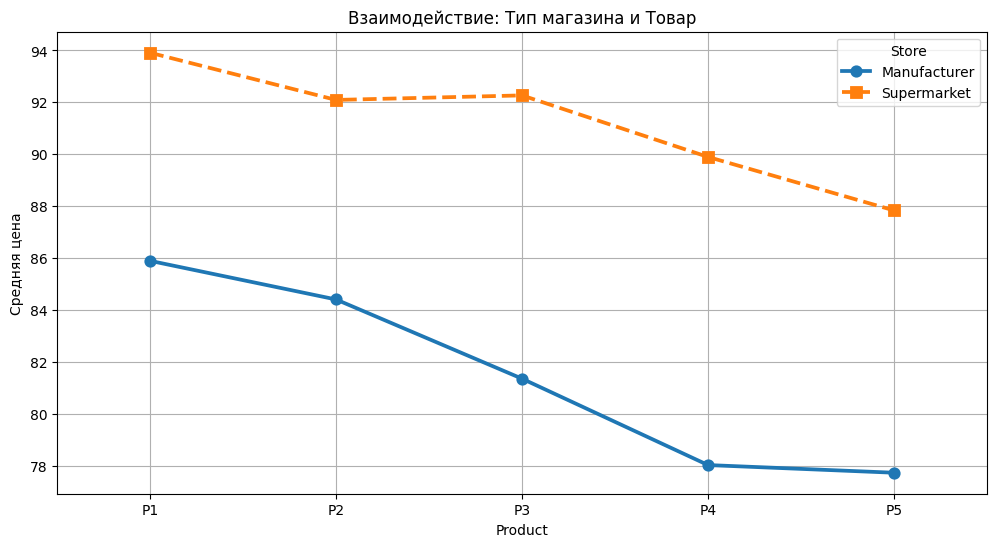

In [19]:
import numpy as np
import seaborn as sns

# Эмуляция данных: генерация средних значений (пример)
products = [f"P{i}" for i in range(1, 6)]
weeks = [f"W{i}" for i in range(1, 5)]
store_types = ["Manufacturer", "Supermarket"]

# Генерация DataFrame
np.random.seed(42)
plot_data = pd.DataFrame([
    {
        "Store": store,
        "Product": product,
        "Week": week,
        "Price": (
            80 + 10 * (store == "Supermarket") +
            np.random.normal(0, 3) +
            2 * int(week[-1]) - 1 * int(product[-1])
        )
    }
    for store in store_types
    for product in products
    for week in weeks
])

# Визуализация взаимодействий
plt.figure(figsize=(12, 6))
sns.pointplot(data=plot_data, x="Week", y="Price", hue="Store", ci=None, markers=["o", "s"], linestyles=["-", "--"])
plt.title("Взаимодействие: Тип магазина и Неделя")
plt.ylabel("Средняя цена")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
sns.pointplot(data=plot_data, x="Product", y="Price", hue="Store", ci=None, markers=["o", "s"], linestyles=["-", "--"])
plt.title("Взаимодействие: Тип магазина и Товар")
plt.ylabel("Средняя цена")
plt.grid(True)
plt.show()

График 1: Взаимодействие типа магазина и недели.

Супермаркет всегда дороже, но:

Рост цен у Manufacturer более плавный и постепенный.

Параллельность линий → взаимодействие незначительно (и действительно, p = 0.243 из таблицы ANOVA).

График 2: Взаимодействие типа магазина и товара

Линии пересекаются или сходятся, особенно в районе P3–P5.

Это говорит о том, что разница между магазинами зависит от товара: например, на одни товары супермаркет делает большую наценку, на другие — меньшую.